# Overtake Probability Model v2 — Enriched Data

**Training data:** 2022 + 2023 + 2024 seasons (GroupKFold cross-validation by race)  
**Test data:** 2025 season (true holdout — unseen during training)

Uses **data/v2** (45-column battles: year, race context, speed traps, stint, weather).
Improvements over model_testing_1:
- **Temporal split**: train on earlier years, validate on latest (when multiple years present)
- **GroupKFold by race_name** for robust cross-validation
- **Extended features**: gap_ahead, race_progress, position, speed traps, weather, stint/fresh_tyre
- **No driver identity**; qualification_rank_difference only
- **Metrics**: ROC-AUC, PR-AUC, Brier, calibration; threshold tuning

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve, roc_curve, f1_score,
    classification_report, confusion_matrix,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

## 1. Load v2 data — train (2022–2024) and test (2025)

In [2]:
from pathlib import Path

TRAIN_YEARS = [2022, 2023, 2024]
TEST_YEARS  = [2025]

DATA_DIR = Path("../data/v2")

def load_years(years):
    frames = []
    for yr in years:
        p = DATA_DIR / f"battles_{yr}.csv"
        if not p.exists():
            print(f"WARNING: {p} not found — skipping {yr}")
            continue
        frames.append(pd.read_csv(p, encoding="utf-8"))
        print(f"  {yr}: {len(frames[-1]):,} battles")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("Training data (2022-2024):")
df_train = load_years(TRAIN_YEARS)
print(f"  Total train rows : {len(df_train):,}")
print(f"  Overtake rate    : {df_train['overtake'].mean():.2%}")
print(f"  Races            : {df_train['race_name'].nunique()}")
print()
print("Test data (2025 holdout):")
df_test = load_years(TEST_YEARS)
if not df_test.empty:
    print(f"  Total test rows  : {len(df_test):,}")
    print(f"  Overtake rate    : {df_test['overtake'].mean():.2%}")
    print(f"  Races            : {df_test['race_name'].nunique()}")
else:
    print("  No 2025 data yet — holdout evaluation will be skipped")


Training data (2022-2024):
  2022: 12,153 battles
  2023: 12,330 battles
  2024: 13,106 battles
  Total train rows : 37,589
  Overtake rate    : 4.24%
  Races            : 18

Test data (2025 holdout):
  2025: 14,071 battles
  Total test rows  : 14,071
  Overtake rate    : 3.92%
  Races            : 17


## 2. Feature engineering (v2)

In [3]:
def add_features(df):
    df = df.copy()
    df["qualification_rank_difference"] = (
        df["attacker_qualification_rank"] - df["defender_qualification_rank"]
    )
    return df

df_train = add_features(df_train)
if not df_test.empty:
    df_test = add_features(df_test)

DROP_COLS = [
    "attacker", "defender", "overtake", "track",
    "attacker_qualification_rank", "defender_qualification_rank",
]

FEATURE_COLS = [c for c in df_train.columns if c not in DROP_COLS]
TARGET = "overtake"

print("Features:", FEATURE_COLS)
print(f"Count: {len(FEATURE_COLS)}")


Features: ['year', 'race_name', 'lap_number', 'total_laps', 'race_progress', 'attacker_position', 'defender_position', 'attacker_lap_time', 'defender_lap_time', 'gap_ahead', 'attacker_speed_i1', 'defender_speed_i1', 'attacker_speed_i2', 'defender_speed_i2', 'attacker_finish_line_speed', 'defender_finish_line_speed', 'attacker_straight_speed', 'defender_straight_speed', 'safety_car', 'yellow_flag', 'attacker_tyre_compound', 'defender_tyre_compound', 'attacker_tyre_age', 'defender_tyre_age', 'tyre_age_difference', 'attacker_stint', 'defender_stint', 'attacker_fresh_tyre', 'defender_fresh_tyre', 'sector', 'sector_type', 'is_in_drs_zone', 'drs_zone_length', 'track_type', 'air_temp', 'track_temp', 'humidity', 'rainfall', 'wind_speed', 'qualification_rank_difference']
Count: 40


In [4]:
# Training set
X = df_train[FEATURE_COLS].copy()
y = df_train[TARGET].astype(int).values
groups = df_train["race_name"].values

cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
print("Categorical:", cat_cols)
print("Numeric:", num_cols)

# Hold-out test set (2025) — prepared here but NOT used until section 10
if not df_test.empty:
    X_test  = df_test[FEATURE_COLS].copy()
    y_test  = df_test[TARGET].astype(int).values
else:
    X_test = y_test = None
    print("No 2025 test data available yet")


Categorical: ['race_name', 'safety_car', 'yellow_flag', 'attacker_tyre_compound', 'defender_tyre_compound', 'attacker_fresh_tyre', 'defender_fresh_tyre', 'sector_type', 'is_in_drs_zone', 'track_type', 'rainfall']
Numeric: ['year', 'lap_number', 'total_laps', 'race_progress', 'attacker_position', 'defender_position', 'attacker_lap_time', 'defender_lap_time', 'gap_ahead', 'attacker_speed_i1', 'defender_speed_i1', 'attacker_speed_i2', 'defender_speed_i2', 'attacker_finish_line_speed', 'defender_finish_line_speed', 'attacker_straight_speed', 'defender_straight_speed', 'attacker_tyre_age', 'defender_tyre_age', 'tyre_age_difference', 'attacker_stint', 'defender_stint', 'sector', 'drs_zone_length', 'air_temp', 'track_temp', 'humidity', 'wind_speed', 'qualification_rank_difference']


## 3. Preprocessing & models

In [5]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

MODELS = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=2000, solver="lbfgs"),
    "Random Forest": RandomForestClassifier(n_estimators=400, class_weight="balanced", max_depth=12, min_samples_leaf=20, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, min_samples_leaf=20, random_state=42),
}

## 4. GroupKFold CV on 2022–2024 training data


In [6]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)
results = {}

for name, clf in MODELS.items():
    print(f"\n{'='*60}\n  {name}\n{'='*60}")
    pipe = Pipeline([("preprocess", preprocessor), ("classifier", clf)])
    probas = cross_val_predict(pipe, X, y, cv=gkf, groups=groups, method="predict_proba", n_jobs=1)[:, 1]
    roc_auc = roc_auc_score(y, probas)
    pr_auc = average_precision_score(y, probas)
    brier = brier_score_loss(y, probas)
    f1 = f1_score(y, (probas >= 0.5).astype(int))
    results[name] = {"probas": probas, "ROC-AUC": roc_auc, "PR-AUC": pr_auc, "Brier": brier, "F1 (t=0.5)": f1}
    print(f"  ROC-AUC: {roc_auc:.4f}  PR-AUC: {pr_auc:.4f}  Brier: {brier:.4f}  F1@0.5: {f1:.4f}")


  Logistic Regression


  ROC-AUC: 0.7122  PR-AUC: 0.1548  Brier: 0.2206  F1@0.5: 0.1438

  Random Forest


  ROC-AUC: 0.7819  PR-AUC: 0.1492  Brier: 0.1096  F1@0.5: 0.2126

  Gradient Boosting


  ROC-AUC: 0.7746  PR-AUC: 0.1370  Brier: 0.0435  F1@0.5: 0.1257


In [7]:
summary = pd.DataFrame({k: {m: v for m, v in v.items() if m != "probas"} for k, v in results.items()}).T
summary.style.format("{:.4f}")

,ROC-AUC,PR-AUC,Brier,F1 (t=0.5)
Logistic Regression,0.7122,0.1548,0.2206,0.1438
Random Forest,0.7819,0.1492,0.1096,0.2126
Gradient Boosting,0.7746,0.1370,0.0435,0.1257


## 5. ROC & PR curves

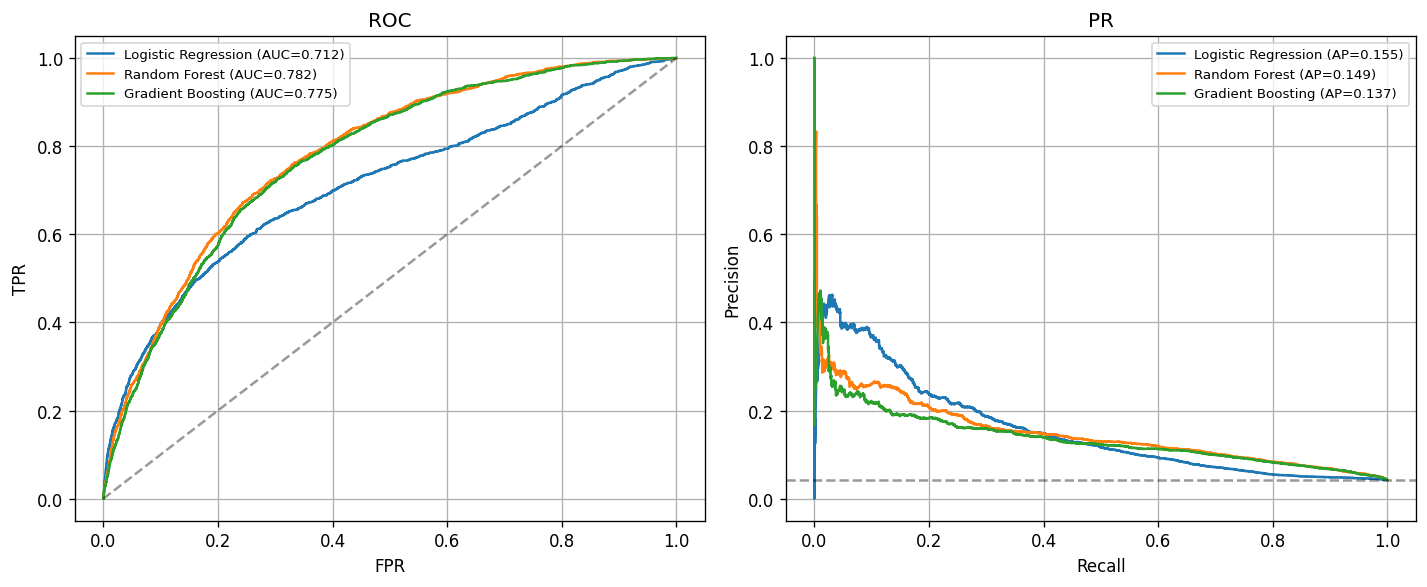

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y, res["probas"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['ROC-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC"); axes[0].legend(fontsize=8)
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y, res["probas"])
    axes[1].plot(rec, prec, label=f"{name} (AP={res['PR-AUC']:.3f})")
axes[1].axhline(y=y.mean(), color="k", ls="--", alpha=0.4)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("PR"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Calibration & threshold tuning

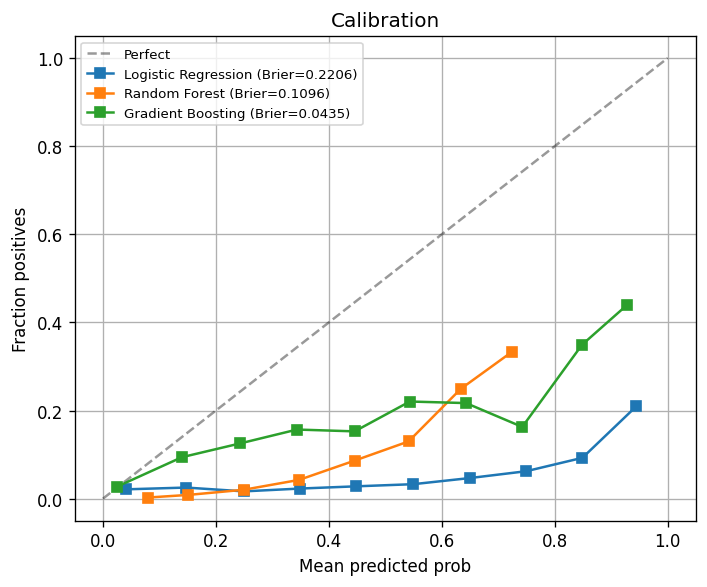

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfect")
for name, res in results.items():
    fp, mp = calibration_curve(y, res["probas"], n_bins=10, strategy="uniform")
    ax.plot(mp, fp, "s-", label=f"{name} (Brier={res['Brier']:.4f})")
ax.set_xlabel("Mean predicted prob"); ax.set_ylabel("Fraction positives"); ax.set_title("Calibration"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

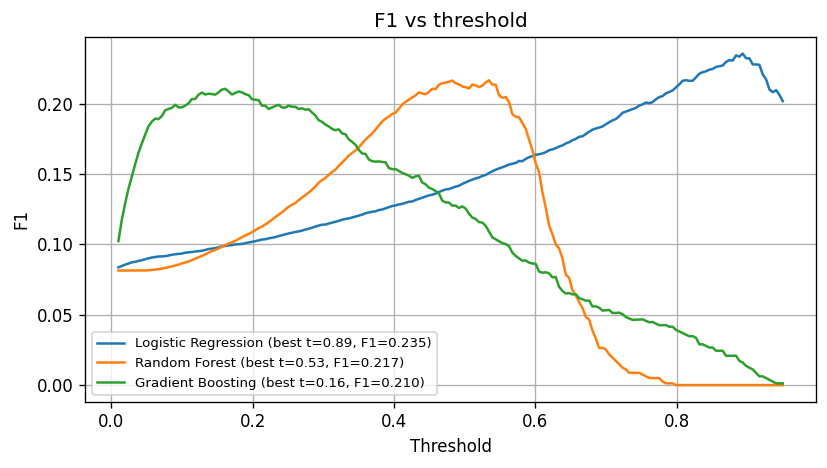


Logistic Regression @ t=0.89
              precision    recall  f1-score   support

 No overtake       0.97      0.95      0.96     35995
    Overtake       0.21      0.27      0.24      1594

    accuracy                           0.92     37589
   macro avg       0.59      0.61      0.60     37589
weighted avg       0.94      0.92      0.93     37589


Random Forest @ t=0.53
              precision    recall  f1-score   support

 No overtake       0.97      0.95      0.96     35995
    Overtake       0.19      0.25      0.22      1594

    accuracy                           0.92     37589
   macro avg       0.58      0.60      0.59     37589
weighted avg       0.93      0.92      0.93     37589


Gradient Boosting @ t=0.16
              precision    recall  f1-score   support

 No overtake       0.97      0.92      0.94     35995
    Overtake       0.15      0.34      0.21      1594

    accuracy                           0.89     37589
   macro avg       0.56      0.63      0.58   

In [10]:
best_thresholds = {}
fig, ax = plt.subplots(figsize=(7, 4))
for name, res in results.items():
    thresholds = np.linspace(0.01, 0.95, 200)
    f1s = [f1_score(y, (res["probas"] >= t).astype(int), zero_division=0) for t in thresholds]
    best_idx = np.argmax(f1s)
    best_t, best_f1 = thresholds[best_idx], f1s[best_idx]
    best_thresholds[name] = best_t
    ax.plot(thresholds, f1s, label=f"{name} (best t={best_t:.2f}, F1={best_f1:.3f})")
ax.set_xlabel("Threshold"); ax.set_ylabel("F1"); ax.set_title("F1 vs threshold"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
for name, t in best_thresholds.items():
    preds = (results[name]["probas"] >= t).astype(int)
    print(f"\n{name} @ t={t:.2f}"); print(classification_report(y, preds, target_names=["No overtake", "Overtake"]))

## 7. Best model: calibrated probabilities

In [11]:
best_model_name = max(results, key=lambda k: results[k]["ROC-AUC"])
print(f"Best by ROC-AUC: {best_model_name}")
X_transformed = preprocessor.fit_transform(X)
cal_clf = CalibratedClassifierCV(MODELS[best_model_name], method="isotonic", cv=5)
cal_clf.fit(X_transformed, y)
cal_probas = cal_clf.predict_proba(X_transformed)[:, 1]
print(f"Calibrated Brier: {brier_score_loss(y, cal_probas):.4f}")

Best by ROC-AUC: Random Forest


Calibrated Brier: 0.0285


## 8. Confusion matrix (best model, tuned threshold)

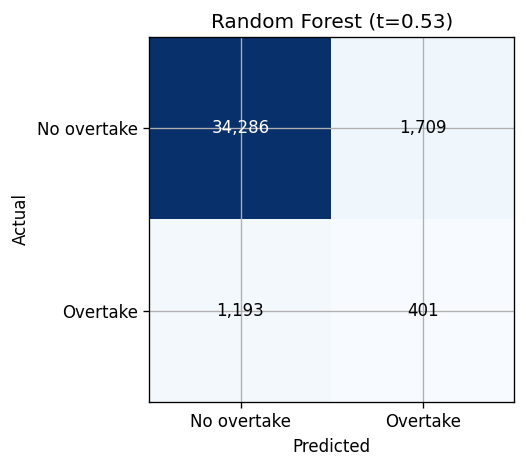

In [12]:
best_t = best_thresholds[best_model_name]
best_preds = (results[best_model_name]["probas"] >= best_t).astype(int)
cm = confusion_matrix(y, best_preds)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["No overtake", "Overtake"]); ax.set_yticklabels(["No overtake", "Overtake"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(f"{best_model_name} (t={best_t:.2f})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center", color="white" if cm[i,j] > cm.max()/2 else "black")
plt.tight_layout(); plt.show()

## 9. Save the model trained on 2022–2024

Retrain on **all 2022–2024 data** and serialise the full pipeline (preprocessor + calibrated classifier) to `models/artifacts/`. This is the artefact used by `predict.py` to score new battles.


In [13]:
import joblib
from pathlib import Path

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

# ── retrain on full 2022-2024 dataset ─────────────────────────
final_clf = MODELS[best_model_name]
final_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
X_all = final_preprocessor.fit_transform(X)  # X is 2022-2024
final_cal = CalibratedClassifierCV(final_clf, method="isotonic", cv=5)
final_cal.fit(X_all, y)

# ── bundle preprocessor + classifier into a single pipeline ───
full_pipeline = Pipeline([
    ("preprocess", final_preprocessor),
    ("classifier", final_cal),
])

# ── save artefacts ─────────────────────────────────────────────
model_path = ARTIFACTS_DIR / "overtake_model_v2.pkl"
meta_path  = ARTIFACTS_DIR / "overtake_model_v2_meta.json"

joblib.dump(full_pipeline, model_path)

import json as _json, datetime
meta = {
    "model": best_model_name,
    "calibration": "isotonic",
    "features": FEATURE_COLS,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "threshold": float(best_thresholds[best_model_name]),
    "train_years": TRAIN_YEARS,
    "train_rows": int(len(X)),
    "overtake_rate": float(y.mean()),
    "saved_at": datetime.datetime.now().isoformat(),
}
meta_path.write_text(_json.dumps(meta, indent=2))

print(f"Model saved   → {model_path}")
print(f"Metadata saved → {meta_path}")
print(f"Trained on     : {TRAIN_YEARS}  ({len(X):,} battles)")
print(f"Decision threshold: {meta['threshold']:.3f}")


Model saved   → artifacts/overtake_model_v2.pkl
Metadata saved → artifacts/overtake_model_v2_meta.json
Trained on     : [2022, 2023, 2024]  (37,589 battles)
Decision threshold: 0.534


## 10. Holdout evaluation on 2025 data

The model is now applied to the **unseen 2025 season**. No 2025 data was used for training or threshold selection.


In [14]:
if X_test is not None and y_test is not None:
    # Use the full_pipeline trained on 2022-2024
    probas_2025 = full_pipeline.predict_proba(X_test)[:, 1]
    preds_2025  = (probas_2025 >= best_thresholds[best_model_name]).astype(int)

    from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, classification_report
    print("2025 Holdout Results")
    print("=" * 40)
    print(f"  ROC-AUC  : {roc_auc_score(y_test, probas_2025):.4f}")
    print(f"  PR-AUC   : {average_precision_score(y_test, probas_2025):.4f}")
    print(f"  Brier    : {brier_score_loss(y_test, probas_2025):.4f}")
    print()
    print(classification_report(y_test, preds_2025, target_names=["No overtake", "Overtake"]))

    # Per-race overtake probability
    race_proba = df_test.copy()
    race_proba["predicted_proba"] = probas_2025
    print("\nMean predicted overtake probability by 2025 race:")
    print(
        race_proba.groupby("race_name")["predicted_proba"]
        .mean()
        .sort_values(ascending=False)
        .to_string()
    )
else:
    print("Skipping holdout evaluation — 2025 data not available yet.")
    print("Run:  python src/pipeline/main.py --years 2025 --output data/v2/battles_2025.csv")


2025 Holdout Results
  ROC-AUC  : 0.7851
  PR-AUC   : 0.2001
  Brier    : 0.0345

              precision    recall  f1-score   support

 No overtake       0.96      1.00      0.98     13520
    Overtake       1.00      0.01      0.01       551

    accuracy                           0.96     14071
   macro avg       0.98      0.50      0.50     14071
weighted avg       0.96      0.96      0.94     14071


Mean predicted overtake probability by 2025 race:
race_name
Saudi Arabian Grand Prix    0.062645
Abu Dhabi Grand Prix        0.061915
Italian Grand Prix          0.056402
Azerbaijan Grand Prix       0.055830
Spanish Grand Prix          0.053787
Bahrain Grand Prix          0.049873
United States Grand Prix    0.041210
British Grand Prix          0.040906
Canadian Grand Prix         0.039639
Hungarian Grand Prix        0.035242
Dutch Grand Prix            0.032777
Mexico City Grand Prix      0.031389
Japanese Grand Prix         0.027911
Singapore Grand Prix        0.026378
Australian G